<div>
<img src=https://www.institutedata.com/wp-content/uploads/2019/10/iod_h_tp_primary_c.svg width="300">
</div>

# Data Science and AI
## Lab 7.1.1: Decision Trees

INSTRUCTIONS:

- Read the guides and hints, then create the necessary analysis and code for the scenario below.
- The baseline results (minimum) are:
    - **Accuracy** = 0.6895
    - **ROC AUC**  = 0.5690
- Try to achieve better results!

# Foreword
It is common that companies and professionals start with the data immediately available. Although this approach works, ideally the first step is to identify the problem or question and only then identify and obtain the set of data that can help to solve or answer the problem.

Also, given the current abundance of data, processing power and some particular machine learning methods, there could be a temptation to use ALL the data available. **Quality** is _**better**_ than **Quantity**!

Part of calling this discipline **Data Science** is that it is supposed to follow a process and not reach conclusions without support from evidence.

Moreover, it is a creative, exploratory, laborious and iterative process. It is part of the process to repeat, review and change when finding a dead-end.

## Scenario:  Predicting whether somebody donated blood in a given month
Blood donations are important in the medical field for a range of reasons, such as assisting patients undergoing surgery, improving the quality of a patient's bloodstream,
managing serious injury/illness or even medical research.

There is a dataset that collects information about how many times a donor donated blood, how much they donated and when they last donated.

Data is courtesy of **Yeh, I-Cheng** via the **UCI Machine Learning** repository:
- Yeh, I-Cheng, Yang, King-Jang, and Ting, Tao-Ming, "Knowledge discovery on RFM model using Bernoulli sequence, "Expert Systems with Applications, 2008, doi:10.1016/j.eswa.2008.07.018.

# Step 1: Define the problem or question
Identify the subject matter and the given or obvious questions that would be relevant in the field.

## Potential Questions
List the given or obvious questions.


- Can we predict whether a donor will donate blood in a given month based on their donation history?

- What factors (e.g., time since last donation, total donations, frequency) are most strongly associated with the likelihood of donating in a given month?

- How much blood did the donor donate previously?

- How accurately can we classify donors as "likely to donate" or "unlikely to donate" in a specific month?

- Is there a seasonal or monthly trend in donation behavior (e.g., more donations during holidays or summer)?

- What is the optimal time to contact a donor based on their donation history to maximise the chance of donation?

# Step 2: Find the Data
### Blood Transfusion Service Center DataSet
- **Abstract**: Data taken from the **Blood Transfusion Service Center** in Hsin-Chu City in Taiwan.
- Date Donated: 2008-10-03
- Source:
        Original Owner and Donor: Prof. I-Cheng Yeh
        Department of Information Management
        Chung-Hua University,
        Hsin Chu, Taiwan 30067, R.O.C.

- Citation Request:
    **NOTE**: Reuse of this database is unlimited with retention of copyright notice for Prof. I-Cheng Yeh and the following published paper:

        Yeh, I-Cheng, Yang, King-Jang, and Ting, Tao-Ming, "Knowledge discovery on RFM model using Bernoulli sequence, "Expert Systems with Applications, 2008
        
### UCI - Machine Learning Repository
- Center for Machine Learning and Intelligent Systems

The [**UCI Machine Learning Repository**](https://archive.ics.uci.edu/ml/datasets/Blood+Transfusion+Service+Center) is a collection of databases, domain theories, and data generators that are used by the machine learning community for the empirical analysis of machine learning algorithms.

# Step 3: Read the Data
- Read the data (transfusion.data)
- Perform some basic structural cleaning to facilitate the work

In [2]:
from google.colab import files
uploaded = files.upload()

Saving transfusion.data to transfusion.data


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
transfusion = 'transfusion.data'
df=pd.read_csv(transfusion)

# Step 4: Explore and Clean the Data
- Perform some initial simple **EDA** (Exploratory Data Analysis)
- Check for
    - **Number of features**
    - **Data types**
    - **Domains, Intervals**
    - **Outliers** (are they valid or spurious data [read or measure errors])
    - **Null** (values not present or coded [as zero of empty strings])
    - **Missing Values** (coded [as zero of empty strings] or values not present)
    - **Coded content** (classes identified by numbers or codes to represent absence of data)

In [4]:
df.head()

,Recency (months),Frequency (times),Monetary (c.c. blood),Time (months),whether he/she donated blood in March 2007
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0


In [5]:
# Check the number of features and rows
print(f"Shape: {df.shape}")  # (rows, columns)

# Check column names and data types
print("\nData Types:")
print(df.dtypes)

# Summary statistics
print("\nSummary Statistics:")
print(df.describe())

Shape: (748, 5)

Data Types:
Recency (months)                              int64
Frequency (times)                             int64
Monetary (c.c. blood)                         int64
Time (months)                                 int64
whether he/she donated blood in March 2007    int64
dtype: object

Summary Statistics:
       Recency (months)  Frequency (times)  Monetary (c.c. blood)  \
count        748.000000         748.000000             748.000000   
mean           9.506684           5.514706            1378.676471   
std            8.095396           5.839307            1459.826781   
min            0.000000           1.000000             250.000000   
25%            2.750000           2.000000             500.000000   
50%            7.000000           4.000000            1000.000000   
75%           14.000000           7.000000            1750.000000   
max           74.000000          50.000000           12500.000000   

       Time (months)  whether he/she donated blood in 

In [6]:
# Check for null/missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check for zeros (if they represent missing data)
print("\nZero Values:")
print((df == 0).sum())


Missing Values:
Recency (months)                              0
Frequency (times)                             0
Monetary (c.c. blood)                         0
Time (months)                                 0
whether he/she donated blood in March 2007    0
dtype: int64

Zero Values:
Recency (months)                                5
Frequency (times)                               0
Monetary (c.c. blood)                           0
Time (months)                                   0
whether he/she donated blood in March 2007    570
dtype: int64


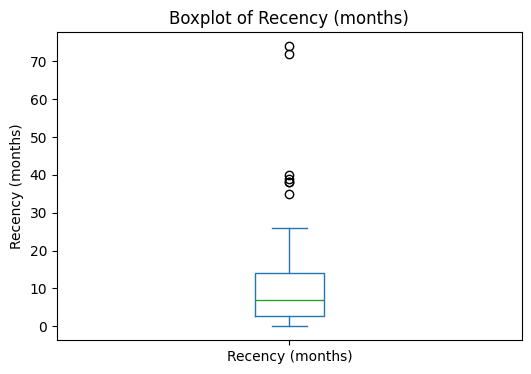

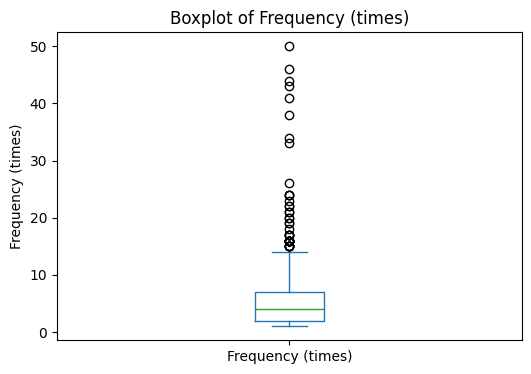

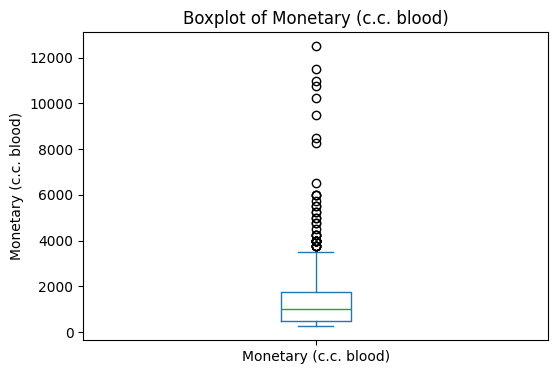

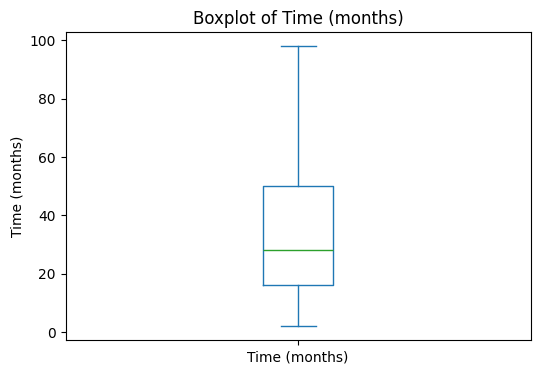

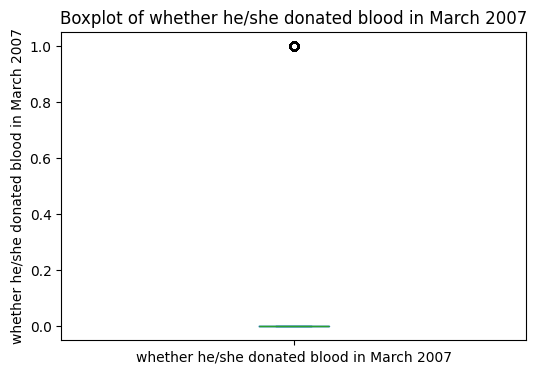

In [7]:
# Create individual boxplots for all numerical columns
for column in df.select_dtypes(include=['int64', 'float64']).columns:
    df[column].plot.box(figsize=(6, 4))
    plt.title(f"Boxplot of {column}")
    plt.ylabel(column)
    plt.show()


Target Class Distribution:
whether he/she donated blood in March 2007
0    570
1    178
Name: count, dtype: int64


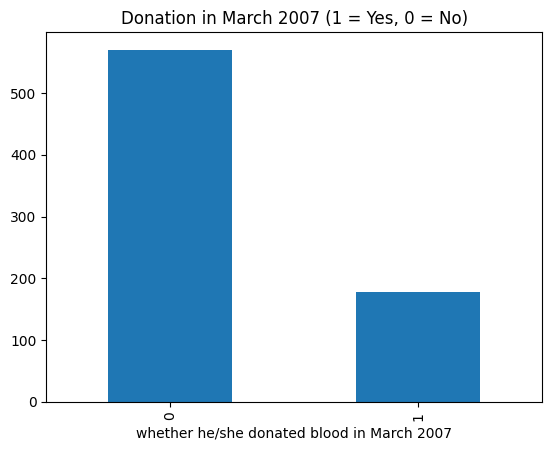

In [8]:
# Check target variable balance
print("\nTarget Class Distribution:")
print(df["whether he/she donated blood in March 2007"].value_counts())

# Plot class distribution
df["whether he/she donated blood in March 2007"].value_counts().plot(kind='bar')
plt.title("Donation in March 2007 (1 = Yes, 0 = No)")
plt.show()

# Step 5: Prepare the Data
- Deal with the data as required by the modelling technique
    - **Outliers** (remove or adjust if possible or necessary)
    - **Null** (remove or interpolate if possible or necessary)
    - **Missing Values** (remove or interpolate if possible or necessary)
    - **Coded content** (transform if possible or necessary [str to number or vice-versa])
    - **Feature Engineer** (if useful or necessary)

In [9]:
# Rename columns for easier handling
df.columns = ['recency', 'frequency', 'monetary', 'time', 'donated_march_2007']
print(df.head())

   recency  frequency  monetary  time  donated_march_2007
0        2         50     12500    98                   1
1        0         13      3250    28                   1
2        1         16      4000    35                   1
3        2         20      5000    45                   1
4        1         24      6000    77                   0


In [10]:
# Check extreme values
high_freq = df[df["frequency"] > 50]
print("Donors with high frequency:")
print(high_freq)

Donors with high frequency:
Empty DataFrame
Columns: [recency, frequency, monetary, time, donated_march_2007]
Index: []


# Step 6: Modelling
Refer to the Problem and Main Question.
- What are the input variables (features)?

The features in the dataset are:

1. recency (months since last donation)

2. frequency (total number of donations)

3. time (months since first donation)

- Is there an output variable (label)?

Yes

- If there is an output variable:
    - What is it?

    donated_march_2007

    - What is its type?

    It is supervised learning, since we have labeled data.

- What type of Modelling is it?
    - [x] Supervised
    - [ ] Unsupervised
- What type of Modelling is it?
    - [ ] Regression
    - [x] Classification (binary)
    - [ ] Classification (multi-class)
    - [ ] Clustering

# Step 7: Split the Data

Need to check for **Supervised** modelling:
- Number of known cases or observations
- Define the split in Training/Test or Training/Validation/Test and their proportions
- Check for unbalanced classes and how to keep or avoid it when splitting

In [20]:
from sklearn.model_selection import train_test_split

X = df.drop('donated_march_2007', axis=1)
y = df['donated_march_2007']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Step 8: Define a Model

Define the model and its hyper-parameters.

Consider the parameters and hyper-parameters of each model at each (re)run and after checking the efficiency of a model against the training and test datasets.

In [21]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)



# Step 9: Fit the Model

In [22]:
# Train the model!

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

# Step 10: Verify and Evaluate the Training Model
- Use the **training** data to make predictions
- What metrics are appropriate for the modelling approach used
- For **Supervised** models:
    - Check the **Training Results** with the **Training Predictions** during development
- Analyse, modify the parameters and hyper-parameters and repeat (within reason) until the model does not improve

In [23]:
y_test_pred = dt_model.predict(X_test)
y_test_proba = dt_model.predict_proba(X_test)[:, 1]


# Step 11: Make Predictions and Evaluate the Test Model
**NOTE**: **Do this only after not making any more improvements in the model**.

- Use the **test** data to make predictions
- For **Supervised** models:
    - Check the **Test Results** with the **Test Predictions**

Decision Tree Accuracy: 0.7133
Decision Tree ROC AUC Score: 0.6139
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.83      0.82       114
           1       0.39      0.33      0.36        36

    accuracy                           0.71       150
   macro avg       0.59      0.58      0.59       150
weighted avg       0.70      0.71      0.71       150



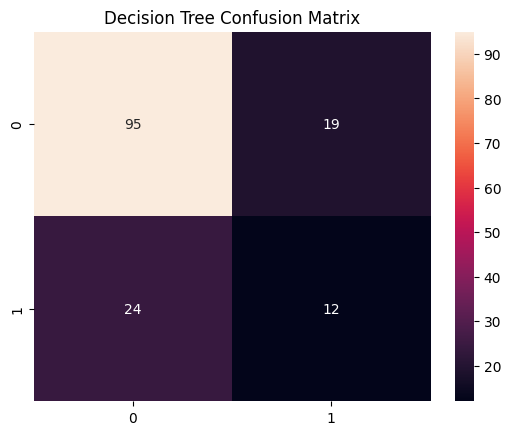

In [24]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Accuracy and ROC AUC
accuracy = accuracy_score(y_test, y_test_pred)
roc_auc = roc_auc_score(y_test, y_test_proba)

print("Decision Tree Accuracy:", round(accuracy, 4))
print("Decision Tree ROC AUC Score:", round(roc_auc, 4))

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_test_pred))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d')
plt.title("Decision Tree Confusion Matrix")
plt.show()


# Step 12: Solve the Problem or Answer the Question
The results of an analysis or modelling can be used:
- As part of a product or process, so the model can make predictions when new input data is available
- As part of a report including text and charts to help understand the problem
- As input for further questions

Using a Decision Tree classifier, the model achieved a test accuracy of 71.3% and an ROC AUC score of 0.6139. While the accuracy is moderately acceptable, the lower ROC AUC indicates that the model struggles to distinguish between donors and non-donors compared to logistic regression and random forest. This suggests that the decision tree may be overfitting or not capturing the patterns in the data as effectively, and further tuning or more robust models may be needed for better performance.



---



---



> > > > > > > > > © 2025 Institute of Data


---



---



